# 🏠 customer messages Data Exploration
This notebook performs initial data exploration on the `twitter messages .csv` dataset.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

In [5]:
df = pd.read_csv('../data/interim/twitter_messages_v1.csv', parse_dates=['created_at'])

print("Dataset loaded with shape:", df.shape)


Dataset loaded with shape: (50838, 8)


In [6]:
df

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,sentiment
0,700,115854,True,2017-10-31 22:16:56+00:00,@applesupport why are my i️’s changing not sho...,698,NaN,positive
1,714,115856,True,2017-10-31 22:19:32+00:00,hey @applesupport and anyone else who upgraded...,"712,715",NaN,neutral
2,723,115859,True,2017-10-31 22:11:16+00:00,@115858 @applesupport hello are all the lines ...,722,NaN,negative
3,730,115861,True,2017-10-31 20:46:35+00:00,"hello, internet. can someone explain why this ...","729,731",NaN,neutral
4,733,115863,True,2017-10-31 22:16:40+00:00,@applesupport i’ve got a screenshot saying my ...,732,NaN,neutral
...,...,...,...,...,...,...,...,...
50833,2987482,823733,True,2017-11-22 00:40:57+00:00,@applesupport why is my iphone 7 constantly se...,2987481,NaN,neutral
50834,2987605,689907,True,2017-11-22 02:11:43+00:00,hey @applesupport - not being able to duplicat...,2987604,NaN,negative
50835,2987607,823765,True,2017-11-22 02:17:14+00:00,yo @applesupport is that weird glitch w/ the c...,2987606,NaN,negative
50836,2987663,823779,True,2017-11-22 03:24:02+00:00,what the fuck @applesupport my phone keeps ha...,2987662,NaN,negative


In [7]:
print("=== Dataset info ===")
print(df.info())

print("\n=== First 5 rows ===")
print(df.head())


=== Dataset info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50838 entries, 0 to 50837
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   tweet_id                 50838 non-null  int64              
 1   author_id                50838 non-null  int64              
 2   inbound                  50838 non-null  bool               
 3   created_at               50838 non-null  datetime64[ns, UTC]
 4   text                     50838 non-null  object             
 5   response_tweet_id        50838 non-null  object             
 6   in_response_to_tweet_id  0 non-null      float64            
 7   sentiment                50838 non-null  object             
dtypes: bool(1), datetime64[ns, UTC](1), float64(1), int64(2), object(3)
memory usage: 2.8+ MB
None

=== First 5 rows ===
   tweet_id  author_id  inbound                created_at  \
0       700     115854     T

In [8]:
print("\n=== Missing values per column ===")
print(df.isna().sum())



=== Missing values per column ===
tweet_id                       0
author_id                      0
inbound                        0
created_at                     0
text                           0
response_tweet_id              0
in_response_to_tweet_id    50838
sentiment                      0
dtype: int64



=== Distribution of 'inbound' ===
inbound
True    1.0
Name: proportion, dtype: float64


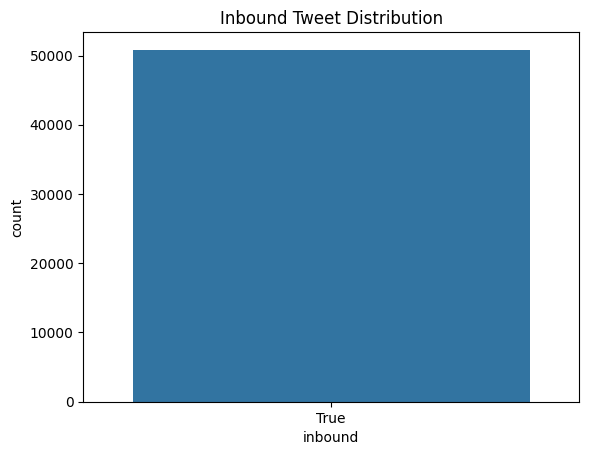

In [9]:
print("\n=== Distribution of 'inbound' ===")
print(df['inbound'].value_counts(normalize=True))

sns.countplot(x='inbound', data=df)
plt.title("Inbound Tweet Distribution")
plt.show()



=== Sentiment distribution ===
sentiment
neutral     0.430347
negative    0.302392
positive    0.267261
Name: proportion, dtype: float64


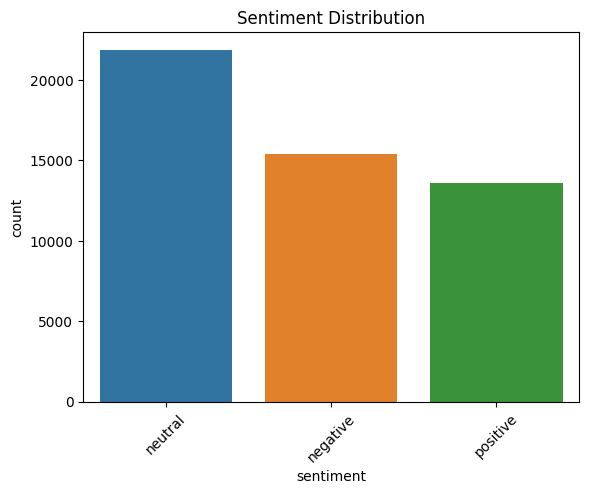

In [10]:
print("\n=== Sentiment distribution ===")
print(df['sentiment'].value_counts(normalize=True))

sns.countplot(x='sentiment', data=df, order=df['sentiment'].value_counts().index)
plt.title("Sentiment Distribution")
plt.xticks(rotation=45)
plt.show()



=== Tweets per day (sample) ===
date
2016-03-04    1
2016-04-04    1
2016-09-06    1
2016-10-01    1
2016-10-06    1
dtype: int64


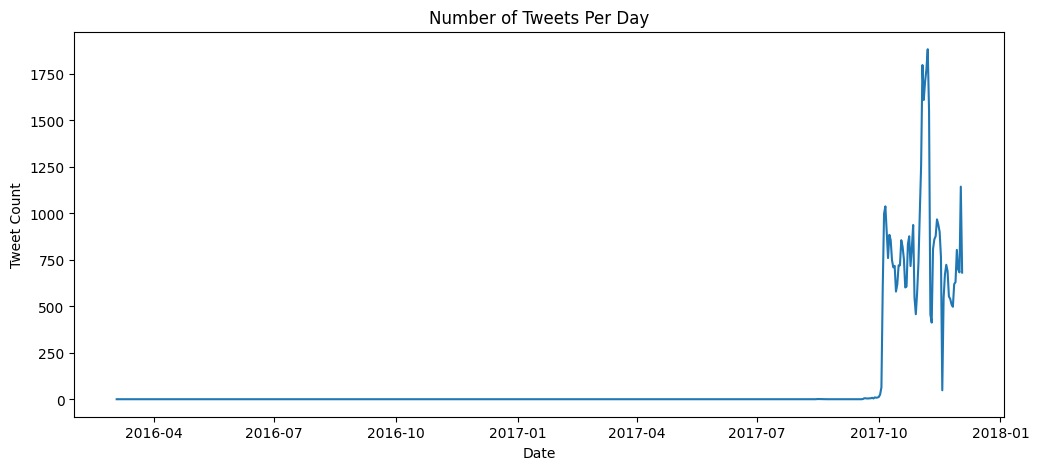

In [11]:
df['date'] = df['created_at'].dt.date
tweets_per_day = df.groupby('date').size()

print("\n=== Tweets per day (sample) ===")
print(tweets_per_day.head())

plt.figure(figsize=(12, 5))
tweets_per_day.plot()
plt.title("Number of Tweets Per Day")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.show()


In [12]:
unique_authors = df['author_id'].nunique()
print(f"\nUnique authors: {unique_authors}")

avg_tweets_per_author = df.shape[0] / unique_authors
print(f"Average tweets per author: {avg_tweets_per_author:.2f}")



Unique authors: 46394
Average tweets per author: 1.10



=== Text length stats ===
count    50838.000000
mean       120.249498
std         47.999777
min         13.000000
25%         87.000000
50%        119.000000
75%        139.000000
max        328.000000
Name: text_length, dtype: float64


/home/nicolas/anaconda3/envs/mlops-env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


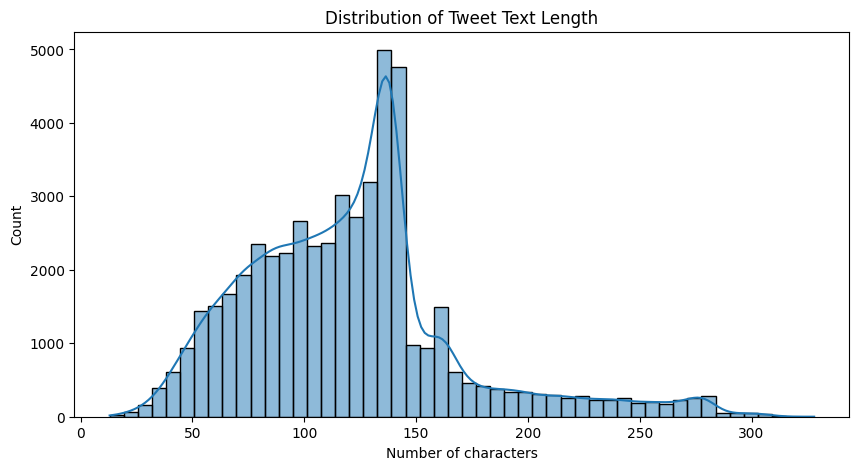

In [13]:
df['text_length'] = df['text'].str.len()

print("\n=== Text length stats ===")
print(df['text_length'].describe())

plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title("Distribution of Tweet Text Length")
plt.xlabel("Number of characters")
plt.show()


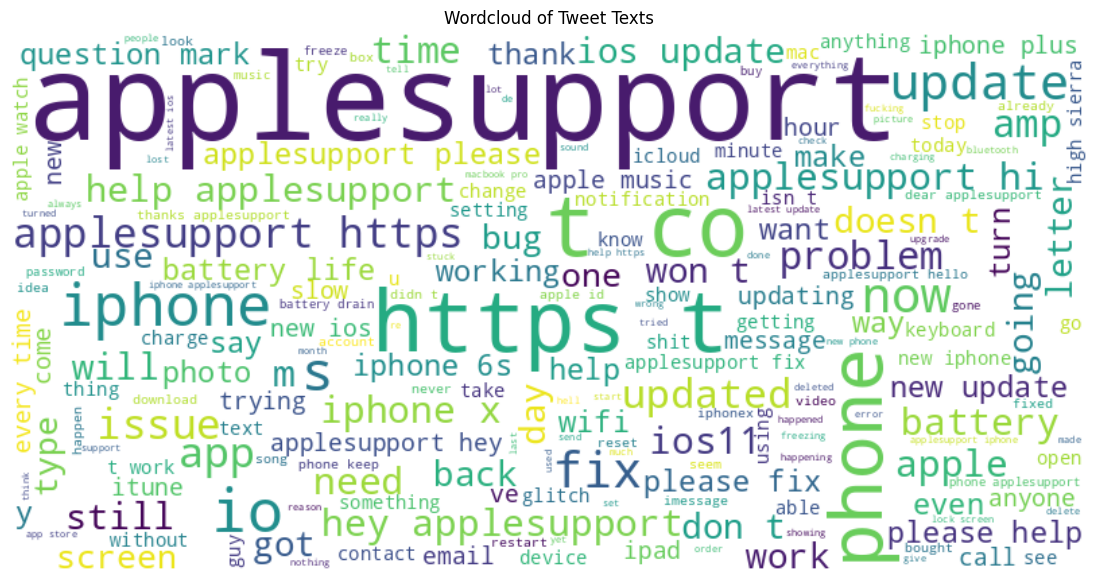

In [14]:
all_text = ' '.join(df['text'].values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud of Tweet Texts")
plt.show()


In [16]:
tokens = re.findall(r'\b\w+\b', all_text.lower())
common_words = Counter(tokens).most_common(20)

print("\nTop 20 most frequent words:")
for word, count in common_words:
    print(f"{word}: {count}")



Top 20 most frequent words:
applesupport: 50974
i: 42223
my: 31498
the: 26267
to: 25886
t: 22565
it: 17656
is: 16660
and: 16284
a: 14860
on: 13146
this: 12712
iphone: 12047
co: 10807
https: 10799
phone: 10476
ios: 9159
can: 8915
11: 8236
in: 8179
